# Data mining<a href="#Data-mining" class="anchor-link">¶</a>

In \[1\]:

    import numpy as np
    import pandas as pd 
    import matplotlib.pyplot as plt
    import seaborn as sns
    from scipy.stats import chi2_contingency
    %matplotlib inline
    import warnings
    warnings.filterwarnings("ignore")

    df_app= pd.read_csv('application_data.csv.zip')
    df_prev= pd.read_csv('previous_application.csv.zip')
    df_col= pd.read_excel('columns_description.xlsx')
    print(df_col)

         Unnamed: 0                     Table                        Row  \
    0             1          application_data                 SK_ID_CURR   
    1             2          application_data                     TARGET   
    2             5          application_data         NAME_CONTRACT_TYPE   
    3             6          application_data                CODE_GENDER   
    4             7          application_data               FLAG_OWN_CAR   
    ..          ...                       ...                        ...   
    155         209  previous_application.csv             DAYS_FIRST_DUE   
    156         210  previous_application.csv  DAYS_LAST_DUE_1ST_VERSION   
    157         211  previous_application.csv              DAYS_LAST_DUE   
    158         212  previous_application.csv           DAYS_TERMINATION   
    159         213  previous_application.csv  NFLAG_INSURED_ON_APPROVAL   

                                               Description  \
    0                             ID of loan in our sample   
    1    Target variable (1 - client with payment diffi...   
    2          Identification if loan is cash or revolving   
    3                                 Gender of the client   
    4                        Flag if the client owns a car   
    ..                                                 ...   
    155  Relative to application date of current applic...   
    156  Relative to application date of current applic...   
    157  Relative to application date of current applic...   
    158  Relative to application date of current applic...   
    159  Did the client requested insurance during the ...   

                                       Special  
    0                                      NaN  
    1                                      NaN  
    2                                      NaN  
    3                                      NaN  
    4                                      NaN  
    ..                                     ...  
    155  time only relative to the application  
    156  time only relative to the application  
    157  time only relative to the application  
    158  time only relative to the application  
    159                                    NaN  

    [160 rows x 5 columns]

## Data Cleaning<a href="#Data-Cleaning" class="anchor-link">¶</a>

Prior to beginning our research, we performed an initial analysis of the
dataframe and discovered the presence of NaN values. This initial data
cleansing procedure has the twin function of simplifying our dataset. It
entails removing extraneous columns, addressing specific subtopics, and
minimizing significant inconsistencies due to missing data.

In \[2\]:

    df_app.isnull().sum()

Out\[2\]:

    SK_ID_CURR                        0
    TARGET                            0
    NAME_CONTRACT_TYPE                0
    CODE_GENDER                       0
    FLAG_OWN_CAR                      0
                                  ...  
    AMT_REQ_CREDIT_BUREAU_DAY     41519
    AMT_REQ_CREDIT_BUREAU_WEEK    41519
    AMT_REQ_CREDIT_BUREAU_MON     41519
    AMT_REQ_CREDIT_BUREAU_QRT     41519
    AMT_REQ_CREDIT_BUREAU_YEAR    41519
    Length: 122, dtype: int64

In \[3\]:

    null_data = df_app.isnull().sum() * 100/len(df_app)
    missing_data_columns = null_data[null_data >= 40]
    missing_data_columns

Out\[3\]:

    OWN_CAR_AGE                     65.990810
    EXT_SOURCE_1                    56.381073
    APARTMENTS_AVG                  50.749729
    BASEMENTAREA_AVG                58.515956
    YEARS_BEGINEXPLUATATION_AVG     48.781019
    YEARS_BUILD_AVG                 66.497784
    COMMONAREA_AVG                  69.872297
    ELEVATORS_AVG                   53.295980
    ENTRANCES_AVG                   50.348768
    FLOORSMAX_AVG                   49.760822
    FLOORSMIN_AVG                   67.848630
    LANDAREA_AVG                    59.376738
    LIVINGAPARTMENTS_AVG            68.354953
    LIVINGAREA_AVG                  50.193326
    NONLIVINGAPARTMENTS_AVG         69.432963
    NONLIVINGAREA_AVG               55.179164
    APARTMENTS_MODE                 50.749729
    BASEMENTAREA_MODE               58.515956
    YEARS_BEGINEXPLUATATION_MODE    48.781019
    YEARS_BUILD_MODE                66.497784
    COMMONAREA_MODE                 69.872297
    ELEVATORS_MODE                  53.295980
    ENTRANCES_MODE                  50.348768
    FLOORSMAX_MODE                  49.760822
    FLOORSMIN_MODE                  67.848630
    LANDAREA_MODE                   59.376738
    LIVINGAPARTMENTS_MODE           68.354953
    LIVINGAREA_MODE                 50.193326
    NONLIVINGAPARTMENTS_MODE        69.432963
    NONLIVINGAREA_MODE              55.179164
    APARTMENTS_MEDI                 50.749729
    BASEMENTAREA_MEDI               58.515956
    YEARS_BEGINEXPLUATATION_MEDI    48.781019
    YEARS_BUILD_MEDI                66.497784
    COMMONAREA_MEDI                 69.872297
    ELEVATORS_MEDI                  53.295980
    ENTRANCES_MEDI                  50.348768
    FLOORSMAX_MEDI                  49.760822
    FLOORSMIN_MEDI                  67.848630
    LANDAREA_MEDI                   59.376738
    LIVINGAPARTMENTS_MEDI           68.354953
    LIVINGAREA_MEDI                 50.193326
    NONLIVINGAPARTMENTS_MEDI        69.432963
    NONLIVINGAREA_MEDI              55.179164
    FONDKAPREMONT_MODE              68.386172
    HOUSETYPE_MODE                  50.176091
    TOTALAREA_MODE                  48.268517
    WALLSMATERIAL_MODE              50.840783
    EMERGENCYSTATE_MODE             47.398304
    dtype: float64

In \[4\]:

    app_df = df_app.drop(columns=missing_data_columns.index)

In \[5\]:

    app_df.shape
    missing_rows = app_df.isnull().sum(axis=1)/app_df.shape[1] 
    assert len(missing_rows[missing_rows > 50]) == 0
    print("we see that none of the rows have more than 50% nan values. so we will proceed with further checks.")
    missing_rows[missing_rows > 50]

    we see that none of the rows have more than 50% nan values. so we will proceed with further checks.

Out\[5\]:

    Series([], dtype: float64)

Now that we removed the values greater then 50%, now we can take care of
the null values, but will try to find the values with which it can be
imputed at later point in time

In \[6\]:

    few_missing_data_col = null_data[(null_data <= 15) & (null_data > 0)].sort_values(ascending=False)
    few_missing_data_col

Out\[6\]:

    AMT_REQ_CREDIT_BUREAU_HOUR    13.501631
    AMT_REQ_CREDIT_BUREAU_DAY     13.501631
    AMT_REQ_CREDIT_BUREAU_WEEK    13.501631
    AMT_REQ_CREDIT_BUREAU_MON     13.501631
    AMT_REQ_CREDIT_BUREAU_QRT     13.501631
    AMT_REQ_CREDIT_BUREAU_YEAR    13.501631
    NAME_TYPE_SUITE                0.420148
    OBS_30_CNT_SOCIAL_CIRCLE       0.332021
    DEF_30_CNT_SOCIAL_CIRCLE       0.332021
    OBS_60_CNT_SOCIAL_CIRCLE       0.332021
    DEF_60_CNT_SOCIAL_CIRCLE       0.332021
    EXT_SOURCE_2                   0.214626
    AMT_GOODS_PRICE                0.090403
    AMT_ANNUITY                    0.003902
    CNT_FAM_MEMBERS                0.000650
    DAYS_LAST_PHONE_CHANGE         0.000325
    dtype: float64

In \[ \]:

    %history

In \[7\]:

    app_df.columns

Out\[7\]:

    Index(['SK_ID_CURR', 'TARGET', 'NAME_CONTRACT_TYPE', 'CODE_GENDER',
           'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL',
           'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'NAME_TYPE_SUITE',
           'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS',
           'NAME_HOUSING_TYPE', 'REGION_POPULATION_RELATIVE', 'DAYS_BIRTH',
           'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'FLAG_MOBIL',
           'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE', 'FLAG_CONT_MOBILE', 'FLAG_PHONE',
           'FLAG_EMAIL', 'OCCUPATION_TYPE', 'CNT_FAM_MEMBERS',
           'REGION_RATING_CLIENT', 'REGION_RATING_CLIENT_W_CITY',
           'WEEKDAY_APPR_PROCESS_START', 'HOUR_APPR_PROCESS_START',
           'REG_REGION_NOT_LIVE_REGION', 'REG_REGION_NOT_WORK_REGION',
           'LIVE_REGION_NOT_WORK_REGION', 'REG_CITY_NOT_LIVE_CITY',
           'REG_CITY_NOT_WORK_CITY', 'LIVE_CITY_NOT_WORK_CITY',
           'ORGANIZATION_TYPE', 'EXT_SOURCE_2', 'EXT_SOURCE_3',
           'OBS_30_CNT_SOCIAL_CIRCLE', 'DEF_30_CNT_SOCIAL_CIRCLE',
           'OBS_60_CNT_SOCIAL_CIRCLE', 'DEF_60_CNT_SOCIAL_CIRCLE',
           'DAYS_LAST_PHONE_CHANGE', 'FLAG_DOCUMENT_2', 'FLAG_DOCUMENT_3',
           'FLAG_DOCUMENT_4', 'FLAG_DOCUMENT_5', 'FLAG_DOCUMENT_6',
           'FLAG_DOCUMENT_7', 'FLAG_DOCUMENT_8', 'FLAG_DOCUMENT_9',
           'FLAG_DOCUMENT_10', 'FLAG_DOCUMENT_11', 'FLAG_DOCUMENT_12',
           'FLAG_DOCUMENT_13', 'FLAG_DOCUMENT_14', 'FLAG_DOCUMENT_15',
           'FLAG_DOCUMENT_16', 'FLAG_DOCUMENT_17', 'FLAG_DOCUMENT_18',
           'FLAG_DOCUMENT_19', 'FLAG_DOCUMENT_20', 'FLAG_DOCUMENT_21',
           'AMT_REQ_CREDIT_BUREAU_HOUR', 'AMT_REQ_CREDIT_BUREAU_DAY',
           'AMT_REQ_CREDIT_BUREAU_WEEK', 'AMT_REQ_CREDIT_BUREAU_MON',
           'AMT_REQ_CREDIT_BUREAU_QRT', 'AMT_REQ_CREDIT_BUREAU_YEAR'],
          dtype='object')

In \[8\]:

    #merging the application_data with previous application data
    all_data_df = pd.merge(left=df_app, right=df_prev,how='inner', on='SK_ID_CURR',suffixes='_x')

## SUBTOPIC 1<a href="#SUBTOPIC--1" class="anchor-link">¶</a>

In \[9\]:

    # Countplot: NAME_EDUCATION_TYPE vs. Repayment Difficulties
    plt.figure(figsize=(10, 5))
    sns.countplot(data=all_data_df, x='NAME_EDUCATION_TYPE', hue='TARGET')
    plt.xticks(rotation=45)
    plt.title('Education Level vs. Repayment Difficulties')
    plt.xlabel('Education Level')
    plt.ylabel('Count')
    plt.legend(title='Repayment Difficulties', labels=['No Difficulties', 'Difficulties'])
    plt.tight_layout()
    plt.show()

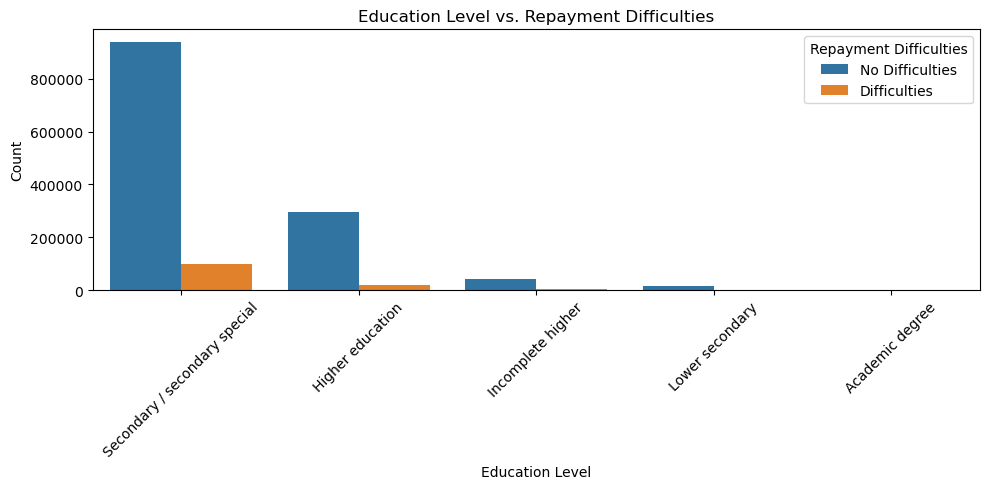

## ANALYSIS TEST<a href="#ANALYSIS-TEST" class="anchor-link">¶</a>

In \[10\]:

    # Calculate descriptive statistics for loan amounts by education level
    education_loan_stats = app_df.groupby('NAME_EDUCATION_TYPE')['AMT_CREDIT'].agg(['mean', 'median', 'std'])
    print(education_loan_stats)

                                            mean    median            std
    NAME_EDUCATION_TYPE                                                  
    Academic degree                723515.625000  610056.0  475701.548980
    Higher education               689950.456100  572076.0  463881.463979
    Incomplete higher              566730.559161  468648.0  392674.695651
    Lower secondary                489748.561321  432949.5  322706.815387
    Secondary / secondary special  571193.392454  497520.0  375794.805810

compare the the loan amount to the new eductated to see how much the
took in the first place.

In \[11\]:

    ### Boxplot: NAME_EDUCATION_TYPE vs. Loan Amount
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=app_df, x='NAME_EDUCATION_TYPE', y='AMT_CREDIT')
    plt.xticks(rotation=45)
    plt.title('Education Level vs. Loan Amount')
    plt.xlabel('Education Level')
    plt.ylabel('Loan Amount')
    plt.tight_layout()
    plt.show()

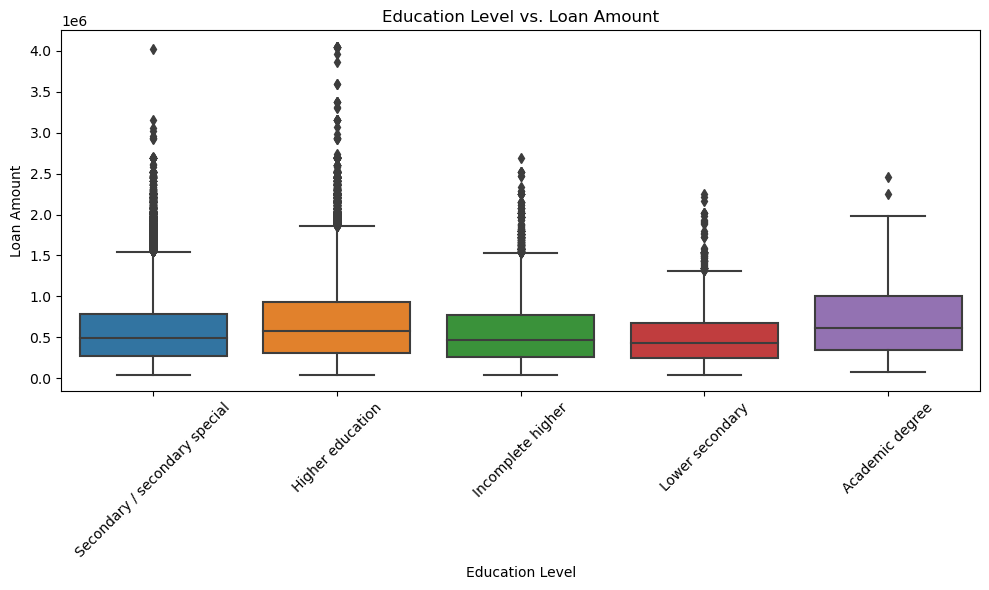

people with academic degress actually took more loan while those with
the secondary degree had more diffcultly paying off. we suspected that
maybe its because of may not have josh.

In \[12\]:

    # Assuming your DataFrame is named 'all_data_df'
    # Subset relevant columns
    education_employment = all_data_df[['NAME_EDUCATION_TYPE', 'DAYS_EMPLOYED']]

    # Group by 'NAME_EDUCATION_TYPE' and calculate statistics on 'DAYS_EMPLOYED'
    education_employment_grouped = education_employment.groupby('NAME_EDUCATION_TYPE').agg(
        Mean_Days_Employed=('DAYS_EMPLOYED', 'mean'),
        Median_Days_Employed=('DAYS_EMPLOYED', 'median'),
        Max_Days_Employed=('DAYS_EMPLOYED', 'max'),
        Min_Days_Employed=('DAYS_EMPLOYED', 'min')
    ).reset_index()

    # Display the grouped data to observe employment effects on education types
    print(education_employment_grouped)

                 NAME_EDUCATION_TYPE  Mean_Days_Employed  Median_Days_Employed  \
    0                Academic degree        51977.639033               -1609.0   
    1               Higher education        41107.091294               -1488.0   
    2              Incomplete higher        19787.022959               -1225.0   
    3                Lower secondary       147211.923736                -474.5   
    4  Secondary / secondary special        77861.440427               -1234.0   

       Max_Days_Employed  Min_Days_Employed  
    0             365243             -11198  
    1             365243             -17170  
    2             365243             -16032  
    3             365243             -15890  
    4             365243             -17912  

In \[13\]:

    # Assuming 'education_employment_grouped' DataFrame contains the grouped data
    # Plotting mean days employed for different education types
    plt.figure(figsize=(10, 6))
    sns.barplot(x='NAME_EDUCATION_TYPE', y='Mean_Days_Employed', data=education_employment_grouped, palette='viridis')
    plt.title('Mean Days Employed for Different Education Types')
    plt.xlabel('Education Type')
    plt.ylabel('Mean Days Employed')
    plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
    plt.tight_layout()
    plt.show()

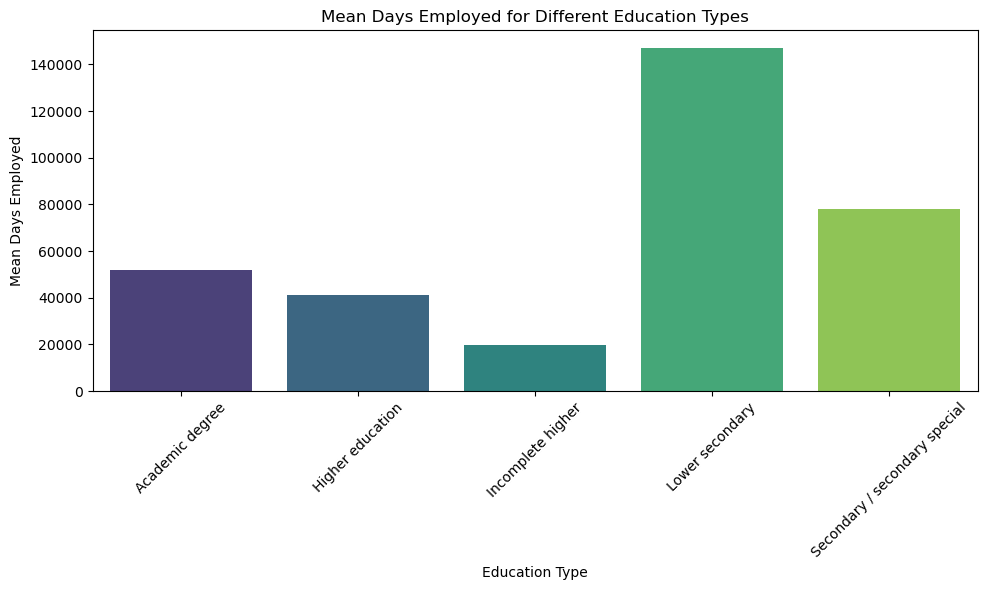

In \[14\]:

    # Assuming 'df_app' contains the application data and 'df_prev' contains previous application data
    # Merging both dataframes to get education type and employment status
    merged_df = pd.merge(df_app, df_prev, how='inner', on='SK_ID_CURR')

    # Grouping by education type and employment status to count the number of employed individuals
    employment_by_education = merged_df[merged_df['DAYS_EMPLOYED'] < 0].groupby(['NAME_EDUCATION_TYPE'])['SK_ID_CURR'].count().reset_index()

    # Plotting count of employed individuals by education type
    plt.figure(figsize=(10, 6))
    sns.barplot(x='NAME_EDUCATION_TYPE', y='SK_ID_CURR', data=employment_by_education, palette='Set2')
    plt.title('Number of Employed Individuals by Education Type')
    plt.xlabel('Education Type')
    plt.ylabel('Count of Employed Individuals')
    plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
    plt.tight_layout()
    plt.show()

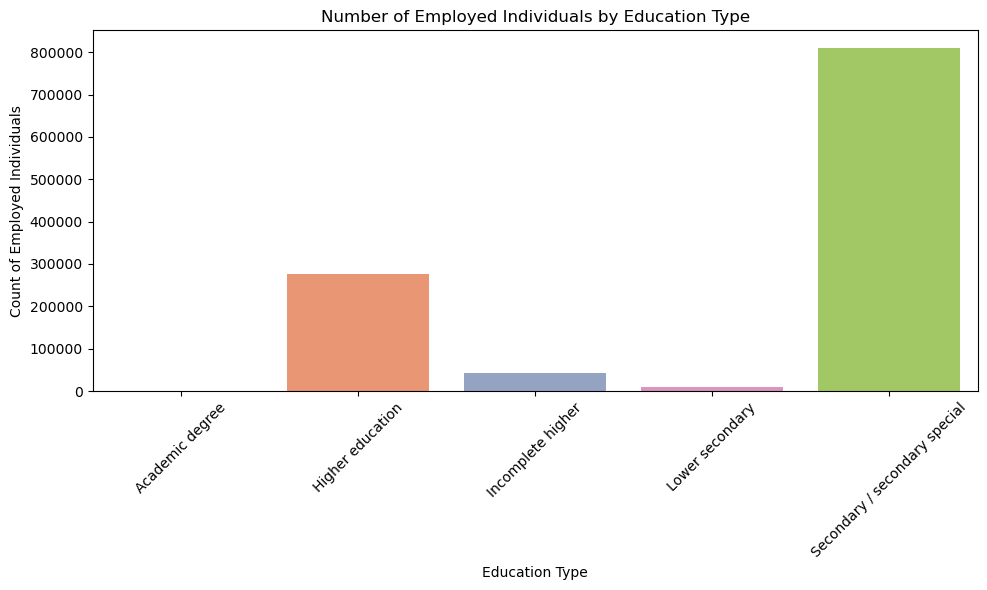

## HYPOTHESIS TEST<a href="#HYPOTHESIS-TEST" class="anchor-link">¶</a>

In \[16\]:

    import pandas as pd
    from scipy.stats import chi2_contingency

    # Assuming df contains your dataset
    # Replace 'Repayment Difficulties' and 'NAME_EDUCATION_TYPE' with actual column names in your dataset
    # Encoding 'Repayment Difficulties' as 'TARGET' variable (0 for no difficulties, 1 for difficulties)

    # Creating a contingency table
    contingency_table = pd.crosstab(app_df['NAME_EDUCATION_TYPE'], app_df['TARGET'])

    # Performing the chi-square test
    chi2, p, dof, expected = chi2_contingency(contingency_table)

    # Displaying the results
    print(f"Chi-square value: {chi2}")
    print(f"P-value: {p}")
    print(f"Degrees of freedom: {dof}")

    Chi-square value: 1019.2131873088356
    P-value: 2.4476812052198174e-219
    Degrees of freedom: 4

its shows that NAME_EDUCATION_TYPE to TARGET is significant.

The following values are connected with a chi-square test:

Chi-square value (2): In a chi-square test of independence, this value
measures the difference between observed and anticipated frequencies. It
denotes how strong the association between category variables is. Higher
chi-square values indicate a stronger relationship between the
variables.

P-value: The p-value in statistical hypothesis testing represents the
likelihood of obtaining outcomes that are as extreme as, or more extreme
than, the observed results, providing the null hypothesis is true. When
the null hypothesis is true, a very low p-value (typically less than
0.05) implies that the observed correlation between the variables is
unlikely to be attributable to random chance. The exceptionally low
p-value (2.4476812052198174e-219) in this situation provides significant
evidence against the hypothesis.

Degrees of freedom: In a chi-square test, degrees of freedom are the
number of variable categories minus one. It is related to the ability to
give values to variables without violating any limitations. With four
degrees of freedom, it implies that at least one of the categorical
variables included in the chi-square test (typically in a contingency
table) has five categories or levels.

Overall, a high chi-square value with an exceptionally low p-value and a
specified degree of freedom shows a significant association between the
categorical variables being evaluated, providing evidence against the
null hypothesis of variable independence.

## CORROLATION<a href="#CORROLATION" class="anchor-link">¶</a>

In \[19\]:

    # Assuming df contains your dataset
    # Replace 'Repayment Difficulties' and 'NAME_EDUCATION_TYPE' with actual column names in your dataset
    # Encoding 'Repayment Difficulties' as 'TARGET' variable (0 for no difficulties, 1 for difficulties)

    # Creating a pivot table to calculate the correlation between 'NAME_EDUCATION_TYPE' and 'TARGET'
    education_target_pivot = all_data_df.pivot_table(index='NAME_EDUCATION_TYPE', columns='TARGET', aggfunc='size', fill_value=0)

    # Calculating the correlation
    correlation = education_target_pivot.corr()

    # Plotting the heatmap to visualize the correlation
    plt.figure(figsize=(10, 6))
    sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f')
    plt.title('Correlation between Education Level and Repayment Difficulties')
    plt.xlabel('Repayment Difficulties')
    plt.ylabel('Education Level')
    plt.xticks(ticks=[0.5, 1.5], labels=['No Difficulties', 'Difficulties'])
    plt.yticks(rotation=0)
    plt.show()

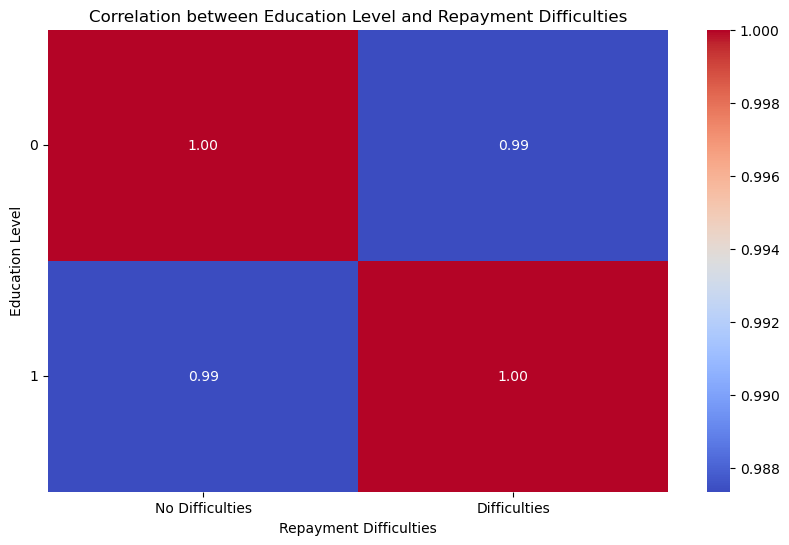

## Linear regression<a href="#Linear-regression" class="anchor-link">¶</a>

In \[21\]:

    # Import necessary libraries
    import pandas as pd
    import statsmodels.api as sm  # Importing statsmodels

    # taking the useful columns
    data = app_df[['NAME_EDUCATION_TYPE', 'TARGET']]

    data = pd.get_dummies(data, columns=['NAME_EDUCATION_TYPE'], drop_first=True)

    # Separating the dependent variable (y) and independent variables (X)
    X = data.drop(columns=['TARGET'])  # Independent variables (excluding loan amount)
    X = sm.add_constant(X)  # Adding a constant for the intercept
    y = data['TARGET']  # Dependent variable (loan amount)

    # Fitting the linear regression model
    model = sm.OLS(y, X).fit()

    # Displaying the regression summary
    print(model.summary())

                                OLS Regression Results                            
    ==============================================================================
    Dep. Variable:                 TARGET   R-squared:                       0.003
    Model:                            OLS   Adj. R-squared:                  0.003
    Method:                 Least Squares   F-statistic:                     255.6
    Date:                Thu, 07 Dec 2023   Prob (F-statistic):          1.06e-219
    Time:                        21:30:23   Log-Likelihood:                -35936.
    No. Observations:              307511   AIC:                         7.188e+04
    Df Residuals:                  307506   BIC:                         7.194e+04
    Df Model:                           4                                         
    Covariance Type:            nonrobust                                         
    =====================================================================================================================
                                                            coef    std err          t      P>|t|      [0.025      0.975]
    ---------------------------------------------------------------------------------------------------------------------
    const                                                 0.0183      0.021      0.861      0.389      -0.023       0.060
    NAME_EDUCATION_TYPE_Higher education                  0.0353      0.021      1.658      0.097      -0.006       0.077
    NAME_EDUCATION_TYPE_Incomplete higher                 0.0666      0.021      3.109      0.002       0.025       0.109
    NAME_EDUCATION_TYPE_Lower secondary                   0.0910      0.022      4.195      0.000       0.048       0.133
    NAME_EDUCATION_TYPE_Secondary / secondary special     0.0711      0.021      3.347      0.001       0.029       0.113
    ==============================================================================
    Omnibus:                   185665.896   Durbin-Watson:                   2.002
    Prob(Omnibus):                  0.000   Jarque-Bera (JB):          1186251.416
    Skew:                           3.062   Prob(JB):                         0.00
    Kurtosis:                      10.421   Cond. No.                         123.
    ==============================================================================

    Notes:
    [1] Standard Errors assume that the covariance matrix of the errors is correctly specified.